In [67]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [68]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')
df.shape

(7043, 21)

### EDA

In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [70]:
df.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6179,6328-ZPBGN,Female,1,No,No,11,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),95.15,997.65,Yes
934,4198-VFOEA,Female,0,No,No,12,No,No phone service,DSL,Yes,...,No,Yes,No,No,One year,Yes,Mailed check,33.60,435.45,No
6238,5188-HGMLP,Male,1,Yes,No,54,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),74.00,3919.15,No
4576,3181-MIZBN,Male,0,Yes,Yes,16,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,19.75,313.4,No
3261,2378-YIZKA,Female,0,Yes,Yes,68,Yes,No,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),85.00,5607.75,No
2228,3597-YASZG,Female,1,Yes,No,70,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),104.45,7349.35,No
3226,0750-EKNGL,Male,0,No,No,7,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.75,141.1,No
1871,3062-ICYZQ,Female,0,Yes,Yes,51,Yes,Yes,Fiber optic,Yes,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,93.80,4539.35,No
5635,2087-QAREY,Female,0,Yes,No,22,Yes,No,DSL,No,...,Yes,No,No,No,Month-to-month,Yes,Mailed check,54.70,1178.75,No
850,6007-TCTST,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),115.80,8476.5,No


In [71]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [72]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [73]:
df.duplicated().sum()

np.int64(0)

In [74]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [75]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

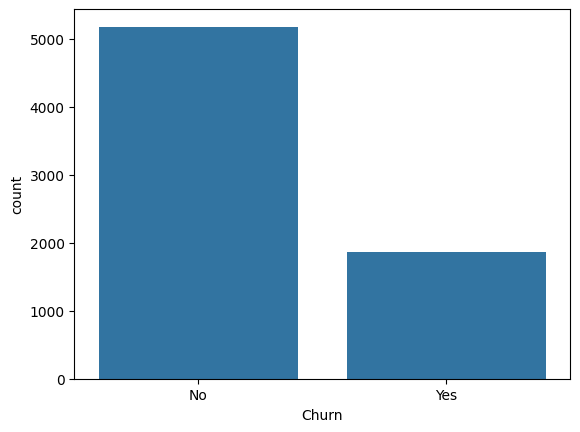

In [76]:
sns.countplot(data=df, x='Churn')
plt.show()

In [77]:
df['TotalCharges'].value_counts().head()

TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
Name: count, dtype: int64

In [78]:
# Changing "TotalCharges" column from string to float
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)  # Replacing empty strings with nan
df['TotalCharges'] = df['TotalCharges'].astype(float)
df['TotalCharges'].dtype

dtype('float64')

In [79]:
df['TotalCharges'].value_counts().head()

TotalCharges
20.20    11
19.75     9
19.90     8
20.05     8
19.65     8
Name: count, dtype: int64

In [80]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

### Univarite analysis on all the int columns

<Axes: xlabel='tenure', ylabel='Count'>

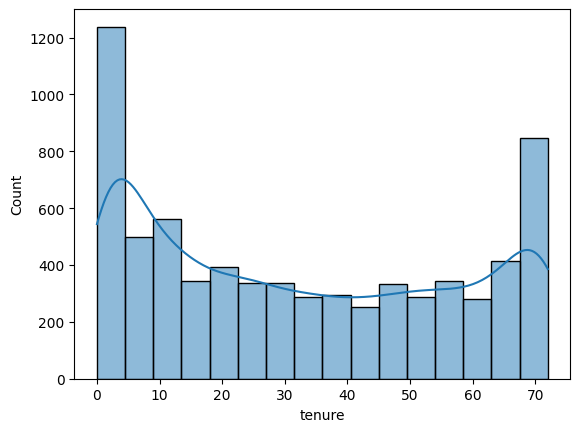

In [81]:
# tenure - Number of months the customer has stayed with the company
sns.histplot(df['tenure'], kde=True)

In [82]:
df['tenure'].value_counts().head(10)

tenure
1     613
72    362
2     238
3     200
4     176
71    170
5     133
7     131
8     123
70    119
Name: count, dtype: int64

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

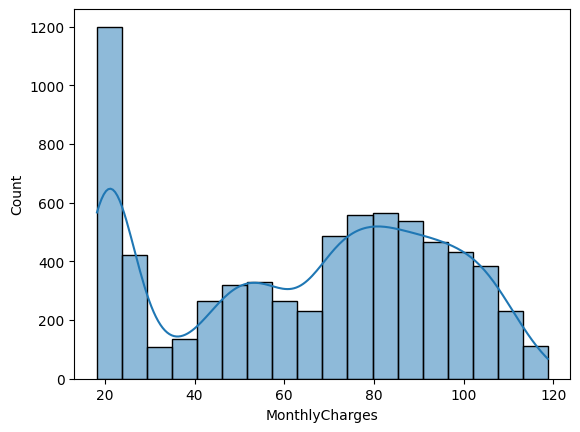

In [83]:
sns.histplot(df['MonthlyCharges'], kde=True)

In [84]:
df['MonthlyCharges'].value_counts().head(10)

MonthlyCharges
20.05    61
19.85    45
19.95    44
19.90    44
19.70    43
19.65    43
20.00    43
20.15    40
19.55    40
19.75    39
Name: count, dtype: int64

<Axes: xlabel='TotalCharges', ylabel='Count'>

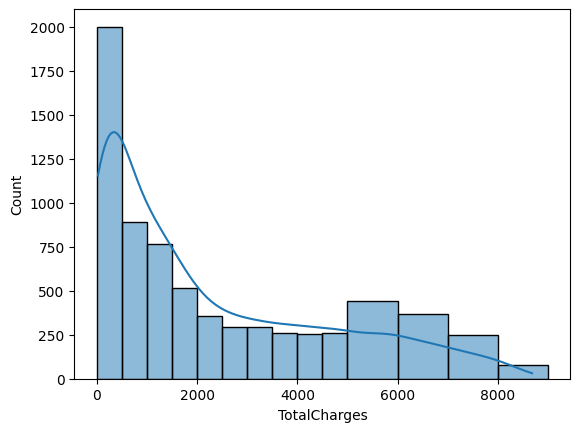

In [85]:
binsA = [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 6000, 7000, 8000, 9000]
sns.histplot(df['TotalCharges'], kde=True, bins=binsA)

### Bivariate analysis

<Axes: xlabel='Contract', ylabel='count'>

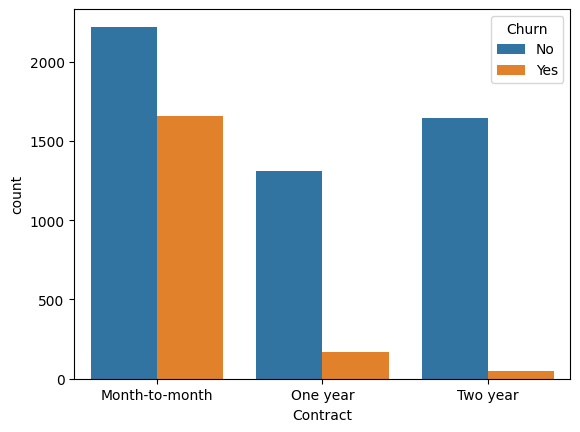

In [86]:
sns.countplot(data=df, x=df['Contract'], hue=df['Churn'])

In [87]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


<Axes: xlabel='InternetService', ylabel='count'>

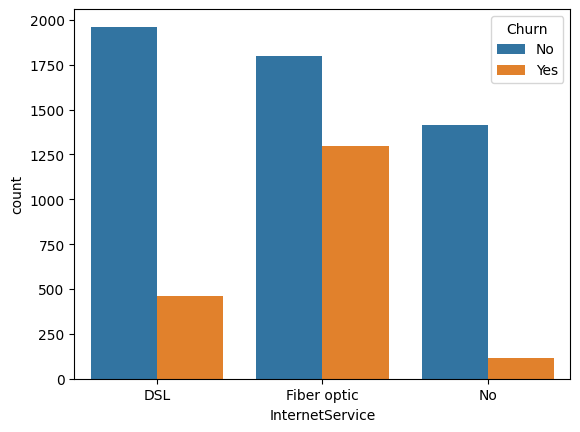

In [88]:
sns.countplot(data=df, x=df['InternetService'], hue=df['Churn'])

In [89]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

<Axes: xlabel='PaymentMethod', ylabel='count'>

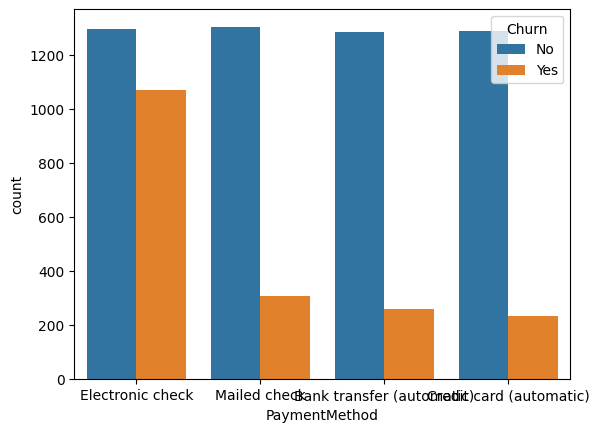

In [90]:
sns.countplot(data=df, x=df['PaymentMethod'], hue=df['Churn'])

In [91]:
pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


### Churn vs tenure

<Axes: xlabel='Churn', ylabel='tenure'>

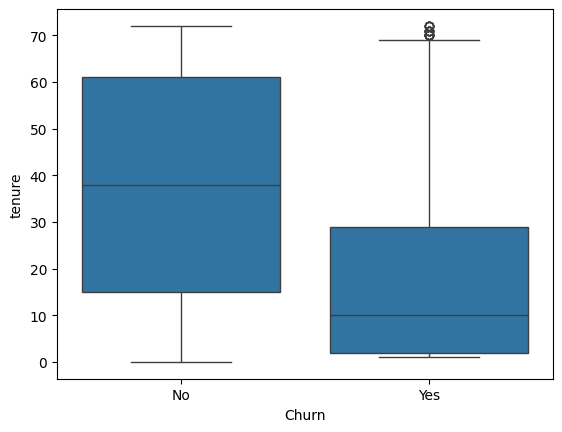

In [92]:
sns.boxplot(data=df, x='Churn', y='tenure')

### Churn vs MonthlyCharges

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

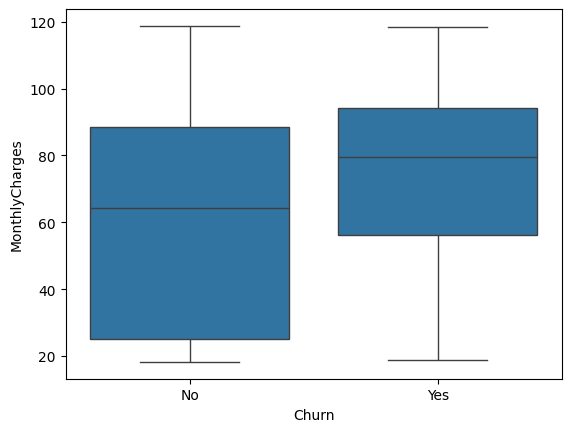

In [93]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

### Contract vs churn percentage

In [94]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


## Learning


### Contract churn rate 

In [95]:
# Normalize attribute is used to convert the output in percentages 
pd.crosstab(df['Contract'], df['Churn'], normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Payment method churn rate

In [96]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


### Internet service churn rate

In [97]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index')*100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


### tenure by contract type

<Axes: xlabel='Contract', ylabel='tenure'>

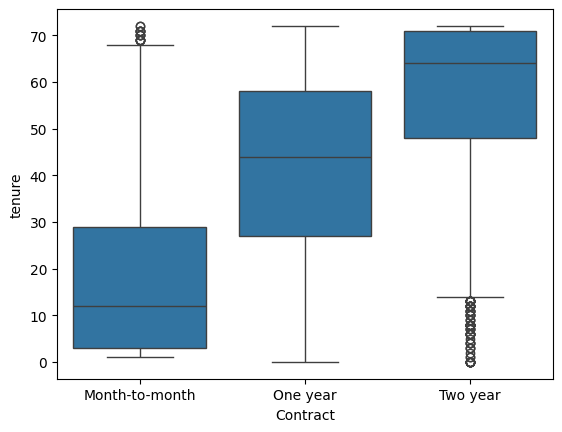

In [98]:
sns.boxplot(
    data=df,
    x='Contract',
    y='tenure'
)

### Is fiber optic associated with higher monthly charges?

<Axes: xlabel='InternetService', ylabel='MonthlyCharges'>

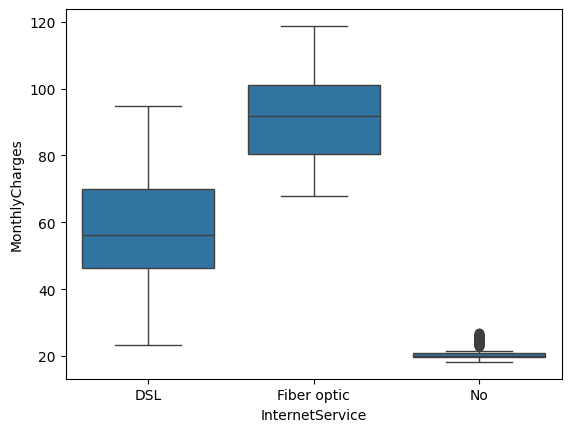

In [99]:
sns.boxplot(data=df, x='InternetService', y='MonthlyCharges')